# CZII - CryoET Object Identification

## Import

In [75]:
import zarr
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn import neighbors
import torch
from torch import nn
import torch.nn.functional as functional
import copy
from utilities import plot_3d_points

In [30]:
for dirname, subdirnames, filenames in os.walk('../data/in/czii-cryo-et-object-identification/test/static/ExperimentRuns/'):
    for subdir in subdirnames:
        print(subdir)
        if 'zarr' in subdir:
            # print(dirname, subdir)
            print(os.path.join(dirname, subdir))
            z1 = zarr.open(os.path.join(dirname, subdir), mode='r')
            break
# for dirname, subdirnames, filenames in os.walk('../data/in/czii-cryo-et-object-identification/train/static/ExperimentRuns/'):
#     for subdir in subdirnames:
#         if 'zarr' in subdir:
#             print(dirname.split('/')[-2], subdir)
#             z1 = zarr.open(os.path.join(dirname, subdir), mode='r')

TS_5_4
TS_69_2
TS_6_4
VoxelSpacing10.000
.zgroup
denoised.zarr
../data/in/czii-cryo-et-object-identification/test/static/ExperimentRuns/TS_5_4/VoxelSpacing10.000/denoised.zarr
VoxelSpacing10.000
.zgroup
denoised.zarr
../data/in/czii-cryo-et-object-identification/test/static/ExperimentRuns/TS_69_2/VoxelSpacing10.000/denoised.zarr
VoxelSpacing10.000
.zgroup
denoised.zarr
../data/in/czii-cryo-et-object-identification/test/static/ExperimentRuns/TS_6_4/VoxelSpacing10.000/denoised.zarr


(184, 630, 630)
(92, 315, 315)
(46, 158, 158)


KeyboardInterrupt: Interrupted by user

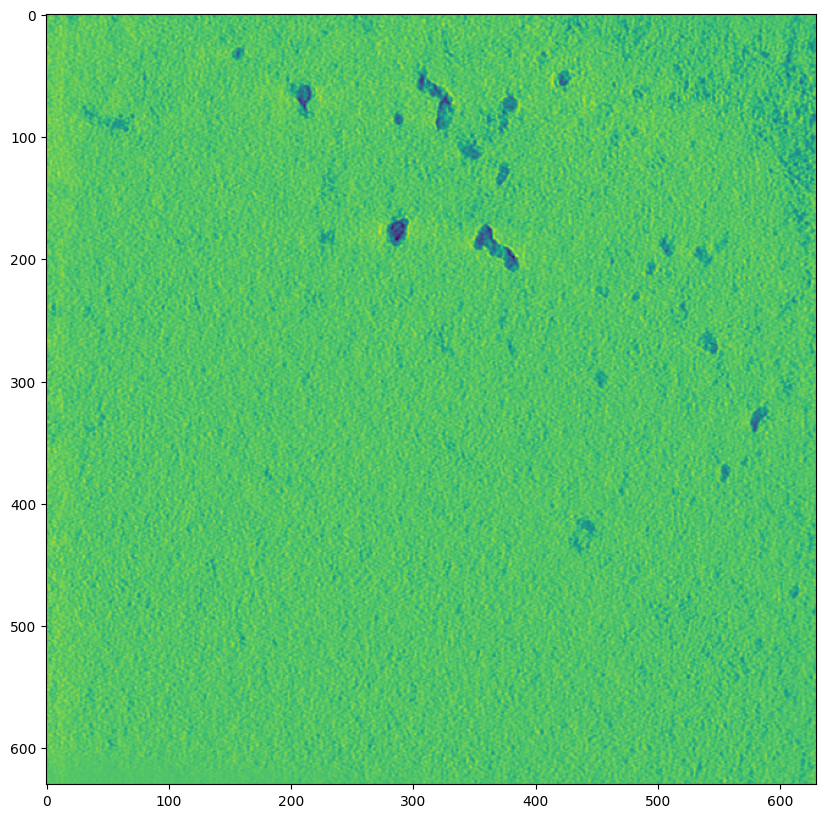

In [120]:
z1 = zarr.open('../data/in/czii-cryo-et-object-identification/test/static/ExperimentRuns/TS_6_4/VoxelSpacing10.000/denoised.zarr', mode='r')
fig = plt.figure(figsize=(10,10))

print(z1[0].shape)
print(z1[1].shape)
print(z1[2].shape)
low = 50
high = low + 3
z1_3d = np.stack(z1[0], 2)
i = 0
while True:
    plt.imshow(z1[0][i])
    i += 1
    input(">>>")
# for i, img in enumerate(z1[0][0]):
#     # if i < low:
#     #     continue
#     # if i > high:
#     #     break
#     ax = plt.subplot(2, 2, i-low+1)
#     _ = plt.imshow(z1[2][1])
#     plt.colorbar()
#     z1_3d = np.array(np.stack([z1[0][0]]))

(46, 158, 158)
0


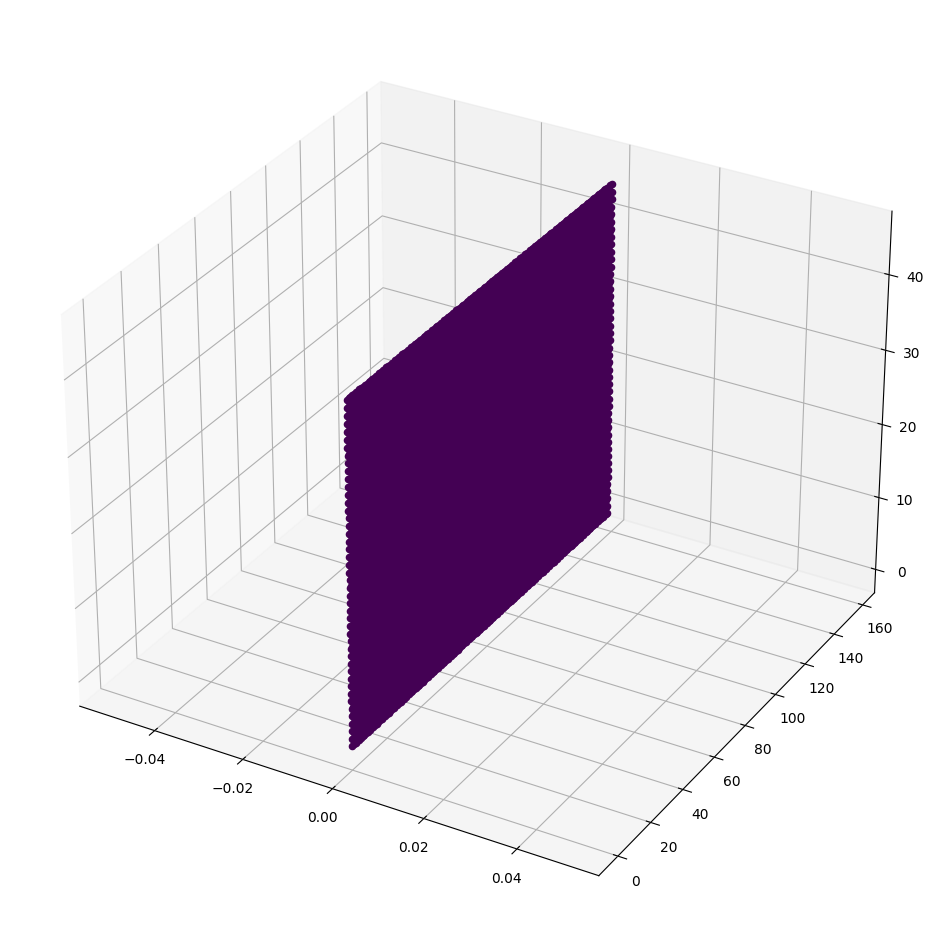

In [108]:
from matplotlib import cm
from matplotlib.colors import Normalize
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
scans = np.array(z1[2])
norm = Normalize(vmin=scans.min(), vmax=scans.max())
# ax.set_box_aspect([1,1,1])
# ax.set_xlim3d([-0.3, 0.3])
# ax.set_ylim3d([-0.3, 0.3])
# ax.set_zlim3d([-0.3, 0.3])
z1_list = np.array(z1[0]).flatten()
print(scans.shape)
i = 0
for z in range(scans.shape[0]):
    for x in range(scans.shape[1]):
        for y in range(scans.shape[2]):
            ax.scatter(x, y, z, color=cm.viridis((scans[x][y][z])))
        break
print(i)